BİLGİSAYARLI TOMOGRAFİ İLE BEYİN KANAMALARININ SINIFLANDIRILMASI - HAFTA 4 ÖDEV

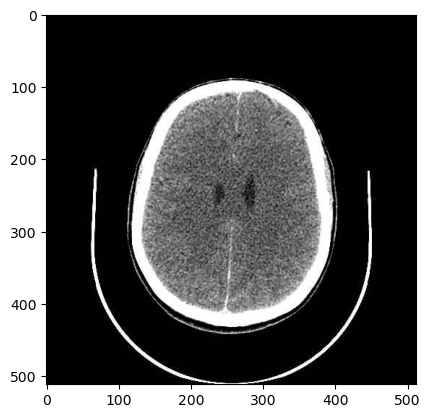

In [25]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('beyin.jpg', 0)
plt.imshow(img, cmap='gray')
plt.show()

Ana hedef olan beyin kanaması sınıflandırması için bir BT kesiti kullanılmıştır. Ham görüntülerdeki düşük kontrast, sınıflandırma programının doğruluğunu düşürdüğü için ön işleme adımları zorunludur.

PİKSEL TABANLI İŞLEM: HISTOGRAM EŞİTLEME

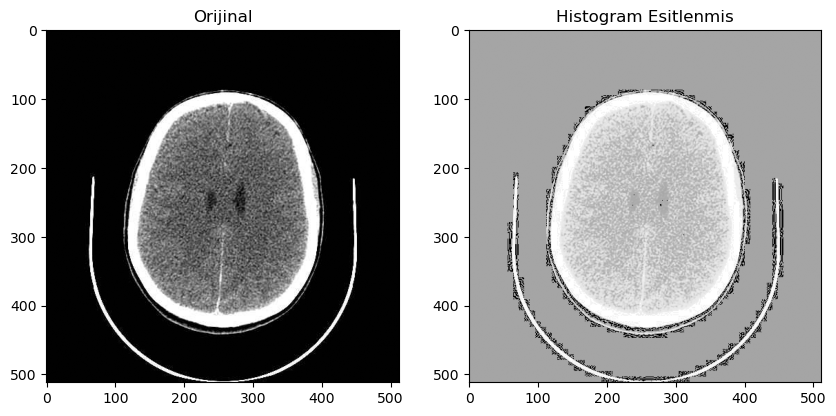

In [26]:
equ = cv2.equalizeHist(img)
plt.figure(figsize=(10,5))
plt.subplot(121), plt.imshow(img, 'gray'), plt.title('Orijinal')
plt.subplot(122), plt.imshow(equ, 'gray'), plt.title('Histogram Esitlenmis')
plt.show()

Histogram eşitleme ile görüntünün kontrastı artırılmıştır. Bu işlem kanama alanları ile beyin dokusu arasındaki farkı belirginleştirerek programın tespit başarısını artırmaktadır.

FİLTRELEME YÖNTEMLERİ: ORTALAMA, GAUSS VE MEDIAN FİLTRELERİ

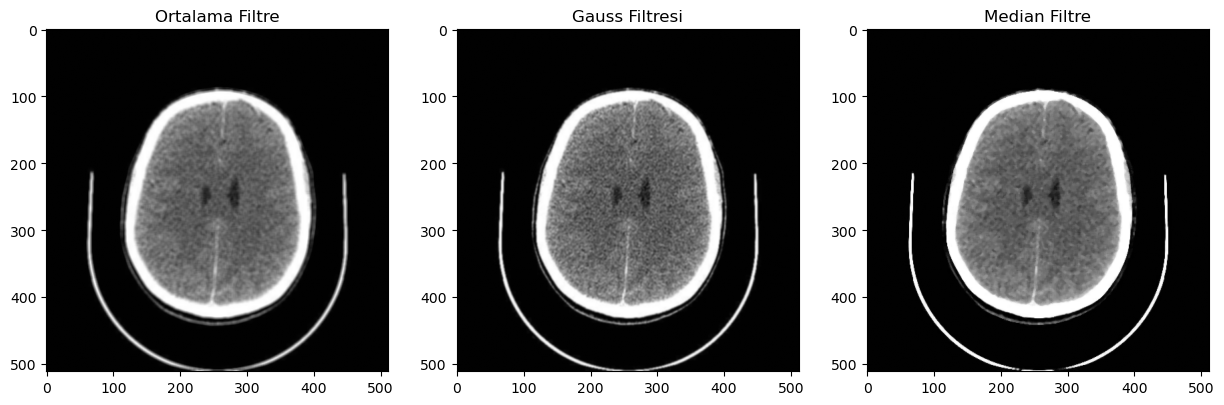

In [27]:
blur_avg = cv2.blur(img, (5,5))
blur_gauss = cv2.GaussianBlur(img, (5,5), 0)
blur_median = cv2.medianBlur(img, 5)

plt.figure(figsize=(15,5))
plt.subplot(131), plt.imshow(blur_avg, 'gray'), plt.title('Ortalama Filtre')
plt.subplot(132), plt.imshow(blur_gauss, 'gray'), plt.title('Gauss Filtresi')
plt.subplot(133), plt.imshow(blur_median, 'gray'), plt.title('Median Filtre')
plt.show()

BT görüntülerindeki parazitleri temizlemek için doğrusal ve doğrusal olmayan filtreler uygulanmıştır. Median Filtre doku detaylarını koruyarak gürültüyü temizlediği için sınıflandırma öncesi en verimli yöntemdir.

KENAR TESPİTİ VE KESKİNLEŞTİRME: LAPLACIAN VE SOBEL FİLTRELERİ

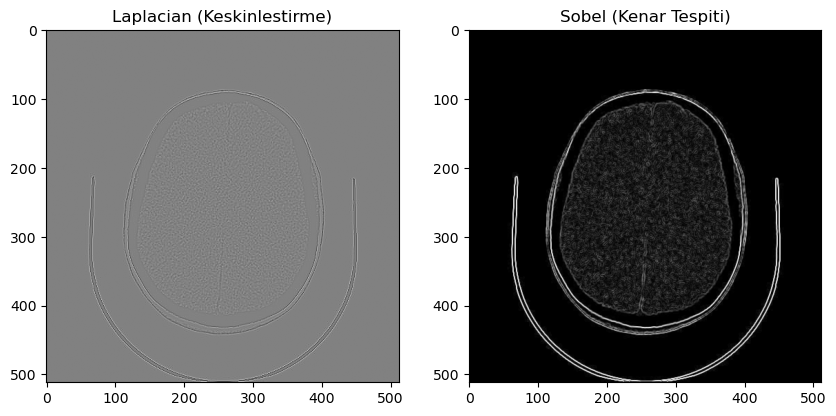

In [28]:
laplacian = cv2.Laplacian(img, cv2.CV_64F)
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

plt.figure(figsize=(10,5))
plt.subplot(121), plt.imshow(laplacian, 'gray'), plt.title('Laplacian (Keskinlestirme)')
plt.subplot(122), plt.imshow(sobel_combined, 'gray'), plt.title('Sobel (Kenar Tespiti)')
plt.show()

Kanama sınırlarını belirlemek amacıyla Sobel ve Laplacian filtreleri kullanılmıştır. Bu sınır bilgileri, programın kanamanın geometrik yapısını daha iyi tanımasını sağlamaktadır.

REFERANSLAR                                                                                                                       

Paulsen, R. R., & Moeslund, T. B. (2020). Introduction to Medical Image Analysis.   
    
Abdulkader, A. (2021). Brain CT Hemorrhage Dataset. Kaggle. 

Gündüz, K. (2023). Derin Öğrenme ile Beyin BT Görüntülerinde Kanama Tespiti. Dergipark.

Demir, A. (2022). Tıbbi Görüntülerde Histogram Analizi ve Sınıflandırma. Dergipark.

Öztürk, M. (2024). Görüntü İşlemede Kenar Tespiti Algoritmaları. Dergipark.